In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [2]:
## state

class State(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    boundary_percentage: float
    balls_per_boundary: float

    summary: str

In [3]:
def calculate_strike_rate(state: State):
    strike_rate =  (state['runs']/state['balls'])*100

    return{
        'strike_rate': strike_rate
    }

In [27]:
def calculate_boundary_percentage(state: State):
    boundary_runs = (state['fours']*4 + state['sixes']*6)

    boundary_percentage = (boundary_runs/state['runs'])*100

    return{
        'boundary_percentage': round(boundary_percentage,2)
    }



In [28]:
def calculate_balls_per_boundary(state: State):
    total_boundaries = state['fours']  + state['sixes']

    balls_per_boundary = state['balls']/total_boundaries

    return{
        'balls_per_boundary': round(balls_per_boundary,2)
    }

In [29]:
def final_summary(state: State):
    summary = f"""
Batsman Performance Summary
---------------------------
Runs: {state['runs']}
Balls: {state['balls']}
Fours: {state['fours']}
Sixes: {state['sixes']}


Strike Rate: {state['strike_rate']: .2f}
Boundary Percentage: {state['boundary_percentage']: .2f}%
Balls per Boundary: {state['balls_per_boundary']: .2f}
"""
 
    return {
        "summary": summary
    }


  

In [30]:
## define the state graph

graph = StateGraph(State)

## add nodes to the graph

graph.add_node('calculate_strike_rate',calculate_strike_rate)

graph.add_node('calculate_boundary_percentage',calculate_boundary_percentage)

graph.add_node('calculate_balls_per_boundary',calculate_balls_per_boundary)

graph.add_node('final_summary',final_summary)



## add edges to the graph

graph.add_edge(START,'calculate_strike_rate')
graph.add_edge(START,'calculate_boundary_percentage')
graph.add_edge(START,'calculate_balls_per_boundary')



graph.add_edge('calculate_strike_rate','final_summary')
graph.add_edge('calculate_boundary_percentage','final_summary')
graph.add_edge('calculate_balls_per_boundary','final_summary')

graph.add_edge('final_summary',END)


workflow = graph.compile()

In [32]:
final_output = workflow.invoke({
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
})

final_output

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'boundary_percentage': 48.0,
 'balls_per_boundary': 5.0,
 'summary': '\nBatsman Performance Summary\n---------------------------\nRuns: 100\nBalls: 50\nFours: 6\nSixes: 4\n\n\nStrike Rate:  200.00\nBoundary Percentage:  48.00%\nBalls per Boundary:  5.00\n'}

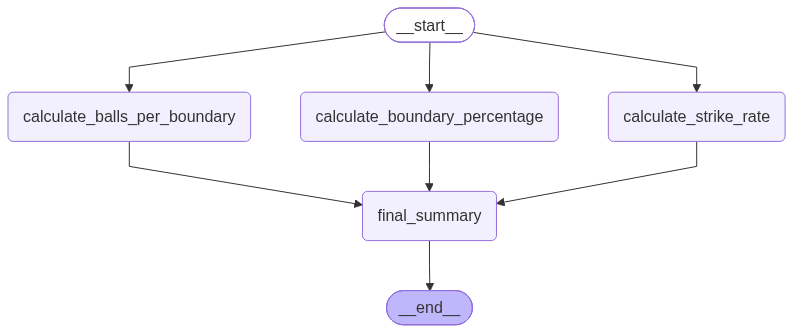

In [33]:
from IPython.display import Image, display

display(
    Image(
        workflow.get_graph().draw_mermaid_png()
    )
)